# 12 — Comparativa de detectores y decisión de diseño (Fase D)

Este notebook consume exclusivamente los artefactos OOS generados por
`04_protocolo_evaluacion.ipynb` o por `python -m regimenes.benchmark`
(`results/benchmark/metrics/*.csv`, `manifest.json` y,
si existen en la máquina, los paneles OOS `panels/*.parquet`). No vuelve a ajustar
modelos, no modifica sus configuraciones y no mezcla las pistas A y B en un ranking único.

> **Objetivo.** Ordenar los detectores con un **criterio de detección explícito**
> (ADR-003): ¿detecta cada crisis evaluada fuera de muestra y con qué precisión, sin
> disparar más falsas alarmas que el azar? La persistencia solo actúa como filtro
> mínimo y desempate. El `rank_medio` de cinco ejes se conserva como columna
> **legacy** para comparar. El notebook no declara automáticamente un ganador.

**Qué contiene:** carga y procedencia (§1), gate de comparabilidad y crisis evaluadas
(§2), **ranking de detección** (§3), frontera de Pareto recall/precisión (§4),
persistencia (§5), mapa de ejes legacy (§6), detección y cobertura por crisis (§7),
robustez: líneas base, parámetros, azar persistente y *leave-one-crisis-out* (§8),
comparación con el `rank_medio` anterior (§9), limitaciones (§10) y lectura final (§11–§12).

Ninguna cifra del texto está escrita a mano: todas salen de las celdas. Las métricas que
se leen son las del benchmark completo (24/24 combinaciones), con las cifras de la
re-ejecución de ADR-003 documentada en su §4. La tabla de procedencia de §1 muestra su
`manifest.json` y la de §3 la fuente de detección (`csv` en todas las filas).

**Notebooks relacionados.** El protocolo común está en
[04 — Protocolo de evaluación](04_protocolo_evaluacion.ipynb). El análisis detallado de
cada detector (teoría, estados OOS, diagnósticos propios, cobertura por crisis y puesto
en este ranking) vive en su notebook de familia; aquí solo se comparan entre sí.

| notebook | familia | detectores |
|---|---|---|
| [05_familia_F1_reglas](05_familia_F1_reglas.ipynb) | F1 Reglas / umbrales | D01 VIX, D02 riesgo compuesto, D10 turbulencia Mahalanobis |
| [06_familia_F2_clustering](06_familia_F2_clustering.ipynb) | F2 Clustering | D03 GMM, D09 Jump Model |
| [07_familia_F3_hmm](07_familia_F3_hmm.ipynb) | F3 HMM | D04 HMM gaussiano, D08 HMM t-Student (D13 HSMM como ablación) |
| [08_familia_F4_markov_switching](08_familia_F4_markov_switching.ipynb) | F4 Markov-switching | D05 MS varianza |
| [09_familia_F5_garch](09_familia_F5_garch.ipynb) | F5 GARCH | D06 GJR-GARCH-t, D11 MS-GARCH |
| [10_familia_F6_changepoint](10_familia_F6_changepoint.ipynb) | F6 Change-point | D07 CUSUM online |
| [11_familia_F7_deep](11_familia_F7_deep.ipynb) | F7 Deep learning | D12 autoencoder + GMM |

Después de esta comparativa: fusiones [13_fusion_d07_d08](13_fusion_d07_d08.ipynb) y
[14_fusion_d02_d06](14_fusion_d02_d06.ipynb).

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from IPython.display import display

warnings.filterwarnings('ignore')

from regimenes.benchmark import load_metrics, metrics_provenance
from regimenes.evaluacion import ranking as rk   # criterio de detección ADR-003
from regimenes.rutas import BENCHMARK_SPEC, RESULTS_BENCHMARK, ROOT

OUTPUT_DIR = RESULTS_BENCHMARK
SPEC = yaml.safe_load(BENCHMARK_SPEC.read_text(encoding='utf-8'))
AXES = {  # eje del ranking -> True si "menor es mejor"
    'mean_crisis_coverage': False,
    'false_alarm_rate': True,
    'mean_trap_activation': True,
    'switching_rate': True,
    'label_stability': False,
}
# Parámetros del criterio de ranking de detección (ADR-003); ver §3.
PARAMS = dict(rk.DETECTION_DEFAULTS)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
print('Resultados:', OUTPUT_DIR.relative_to(ROOT))
print('Parámetros del criterio:', PARAMS)

Resultados: results\benchmark
Parámetros del criterio: {'min_run': 3, 'beta': 1.0, 'lift_min': 1.0, 'min_mean_duration': 5.0, 'min_crisis_run': 3.0, 'score_decimals': 3}


## 1. Carga, inventario y procedencia

Se espera una fila por pista y detector. Una comparación con menos de 12 detectores
puede usarse como diagnóstico, pero debe rotularse como **parcial** y no fundamentar
la decisión final. Las filas A y B nunca compiten directamente: A aporta profundidad
histórica y B riqueza multi-activo.

La carga intenta primero el modo estricto (`require_current=True`): recalcula la huella
de cada CSV con el código, los datos y el entorno locales y exige el panel OOS. Los
paneles OOS y los datos procesados no se versionan, así que en otra máquina esa
verificación puede fallar aunque las métricas sean las correctas. En ese caso se cargan
las métricas versionadas y se comprueba, sin datos locales, que cada CSV lleva la huella
que el `manifest.json` registró en la ejecución original. La tabla de procedencia deja
constancia de qué verificación se ha superado.

In [2]:
VERIFICACION_LOCAL = False
try:
    metrics = load_metrics(OUTPUT_DIR)
    VERIFICACION_LOCAL = True
    HAY_RESULTADOS = True
except FileNotFoundError as exc:
    metrics = pd.DataFrame()
    HAY_RESULTADOS = False
    print(exc)
except RuntimeError as exc:
    print('Verificación local de huella no superada en esta máquina:')
    print('  ', str(exc)[:160], '...')
    print('Se usan las métricas versionadas y se verifica su procedencia contra manifest.json.')
    metrics = load_metrics(OUTPUT_DIR, require_current=False)
    HAY_RESULTADOS = True

if HAY_RESULTADOS:
    provenance = metrics_provenance(OUTPUT_DIR)
    TRAZABLE = bool(len(provenance) and provenance['coincide_manifest'].all())
    print('Ejecución registrada en manifest.json:', provenance.attrs.get('manifest_generated_utc'))
    print('CSV con huella = manifiesto:', int(provenance['coincide_manifest'].sum()), '/', len(provenance))
    print('Verificación local completa (código + datos + entorno):', VERIFICACION_LOCAL)

    inventario = metrics.groupby('pista')['id'].agg(['count', lambda s: ', '.join(sorted(s))])
    inventario.columns = ['n_detectores', 'ids']
    display(inventario)
    completo = metrics.groupby('pista')['id'].nunique().reindex(['A', 'B'], fill_value=0)
    BENCHMARK_COMPLETO = bool((completo == 12).all())
    print('Benchmark completo:', BENCHMARK_COMPLETO)
else:
    BENCHMARK_COMPLETO = False
    TRAZABLE = False

Ejecución registrada en manifest.json: 2026-09-29T12:41:35.741870+00:00
CSV con huella = manifiesto: 24 / 24
Verificación local completa (código + datos + entorno): True


,n_detectores,ids
pista,,
A,12,"D01, D02, D03, D04, D05, D06, D07, D08, D09, D..."
B,12,"D01, D02, D03, D04, D05, D06, D07, D08, D09, D..."


Benchmark completo: True


## 2. Gate de comparabilidad

Antes de ordenar métricas verificamos que dentro de cada pista todos los detectores
comparten inicio, fin y longitud OOS, que no hay duplicados `(pista, id)`, que la
ventana de entrenamiento declarada es común y que las métricas son trazables a la
ejecución registrada. Las distintas frecuencias de *refit* (21 sesiones en general, 63
en D5, 126 en D8/D11) son configuración computacional, no ventanas de evaluación
distintas; su efecto sobre `label_stability` se discute en §10 (limitación 6).

Una discrepancia detiene la interpretación: no se arregla rellenando ni recortando
resultados después de verlos.

In [3]:
if HAY_RESULTADOS:
    duplicates = metrics.duplicated(['pista', 'id']).sum()
    checks = metrics.groupby('pista').agg(
        detectores=('id', 'nunique'),
        inicios_oos=('oos_start', 'nunique'),
        finales_oos=('oos_end', 'nunique'),
        longitudes_oos=('n_oos', 'nunique'),
        train_configs=('train_days', 'nunique'),
    )
    display(checks)
    print('Duplicados pista/id:', duplicates)
    COMPARABLE = bool(
        duplicates == 0
        and (checks[['inicios_oos', 'finales_oos', 'longitudes_oos', 'train_configs']] == 1).all().all()
    )
    print('Gate de comparabilidad:', 'OK' if COMPARABLE else 'FALLA')
    print('Trazabilidad CSV↔manifiesto:', 'OK' if TRAZABLE else 'FALLA')
else:
    COMPARABLE = False

LISTO_COMPARAR = bool(BENCHMARK_COMPLETO and COMPARABLE and TRAZABLE)
if HAY_RESULTADOS and not BENCHMARK_COMPLETO:
    print('Comparación final bloqueada: faltan detectores; termina primero el notebook 04.')

,detectores,inicios_oos,finales_oos,longitudes_oos,train_configs
pista,,,,,
A,12,1,1,1,1
B,12,1,1,1,1


Duplicados pista/id: 0
Gate de comparabilidad: OK
Trazabilidad CSV↔manifiesto: OK


### 2.1 Qué crisis se evalúan realmente fuera de muestra

`benchmark_spec.yaml` asigna 18 crisis a la pista A y 10 a la B, pero el primer
entrenamiento consume ocho años en A y tres en B. La tabla clasifica cada ventana
`[pico, suelo]` frente al rango OOS común: **completa**, **parcial** (el OOS empieza
dentro de la ventana) o **fuera** (NaN para todos los detectores; ni premia ni penaliza).
Los días son sesiones hábiles aproximadas (lunes–viernes), solo informativas.

In [4]:
def estado_ventanas(track):
    part = metrics[metrics.pista == track].iloc[0]
    oos_start, oos_end = pd.Timestamp(part.oos_start), pd.Timestamp(part.oos_end)
    rows = []
    for name, (a, b) in SPEC['crisis_windows'][f'pista_{track}'].items():
        a, b = pd.Timestamp(a), pd.Timestamp(b)
        dias = len(pd.bdate_range(a, b))
        dias_oos = len(pd.bdate_range(max(a, oos_start), min(b, oos_end))) if b >= oos_start else 0
        estado = 'fuera' if dias_oos == 0 else ('completa' if a >= oos_start else 'parcial')
        rows.append({'pista': track, 'crisis': name, 'inicio': a.date(), 'suelo': b.date(),
                     'dias_aprox': dias, 'dias_oos_aprox': dias_oos, 'estado': estado})
    return pd.DataFrame(rows)

if LISTO_COMPARAR:
    ventanas = pd.concat([estado_ventanas(t) for t in ['A', 'B']], ignore_index=True)
    resumen_ventanas = ventanas.groupby(['pista', 'estado']).size().unstack(fill_value=0)
    display(resumen_ventanas)
    display(ventanas[ventanas.estado != 'completa'])
    for t in ['A', 'B']:
        part = metrics[metrics.pista == t].iloc[0]
        print(f"Pista {t}: OOS {part.oos_start} → {part.oos_end} (n={part.n_oos} sesiones)")
    evaluadas = ventanas[ventanas.estado != 'fuera']
    for t, part in evaluadas.groupby('pista'):
        corta, larga = part.loc[part.dias_oos_aprox.idxmin()], part.loc[part.dias_oos_aprox.idxmax()]
        print(f"Pista {t}: {len(part)} crisis evaluadas OOS ({(part.estado == 'parcial').sum()} parcial); "
              f"la más corta {corta.crisis} (~{corta.dias_oos_aprox} sesiones), "
              f"la más larga {larga.crisis} (~{larga.dias_oos_aprox})")

estado,completa,fuera,parcial
pista,,,
A,16,1,1
B,9,1,0


,pista,crisis,inicio,suelo,dias_aprox,dias_oos_aprox,estado
0,A,credit_crunch_1966,1966-02-09,1966-10-07,173,0,fuera
1,A,bear_1969_70,1968-11-29,1970-05-26,388,11,parcial
18,B,gfc_2007_09,2007-10-09,2009-03-09,370,0,fuera


Pista A: OOS 1970-05-12 → 2026-05-29 (n=14133 sesiones)
Pista B: OOS 2010-04-12 → 2026-05-29 (n=4059 sesiones)
Pista A: 17 crisis evaluadas OOS (1 parcial); la más corta volmageddon_2018q1 (~10 sesiones), la más larga dotcom_2000_02 (~664)
Pista B: 9 crisis evaluadas OOS (0 parcial); la más corta volmageddon_2018q1 (~10 sesiones), la más larga inflation_bear_2022 (~203)


**Lectura.** Las crisis que caen en el entrenamiento inicial no se evalúan (NaN: ni
premian ni penalizan) y una ventana solo parcialmente OOS cuenta como un evento
completo. Los episodios son muy desiguales en duración (la salida anterior imprime el
más corto y el más largo): por eso el criterio de §3 cuenta **eventos**, no días, en
el recall, y usa días solo en la precisión.

## 3. Ranking de detección (criterio principal, ADR-003)

**Unidades.** Todo se calcula sobre la señal OOS causal `crisis_t = (state_t == n_states − 1)`
y las ventanas congeladas `[pico, suelo]` de `benchmark_spec.yaml`.

| métrica | definición | papel |
|---|---|---|
| `det_event_recall` | eventos detectados / eventos con días OOS. Un evento está **detectado** si hay al menos `min_run` sesiones OOS **consecutivas** marcadas como crisis dentro de `[pico, suelo]` (todas, si la ventana tiene menos) | sensibilidad por evento |
| `det_precision` | días marcados dentro de alguna ventana / días marcados `= 1 − false_alarm_rate` | especificidad de la alarma |
| `det_base_rate` | fracción de días OOS dentro de ventanas = precisión de marcar crisis **siempre** (y, en esperanza, de cualquier señal independiente de las crisis) | referencia de azar |
| `det_lift_precision` | `det_precision / det_base_rate` (1 = igual que el azar) | restricción de falsas alarmas |
| `score_deteccion` | $F_\beta = (1+\beta^2)\,P\,R\,/\,(\beta^2 P + R)$ con $R$ = recall por evento y $P$ = precisión diaria | **métrica única principal** |

**Orden.** Primero un **nivel** y, dentro de él, el score (desempate con persistencia):

| nivel | condición | lectura |
|---|---|---|
| 0 `elegible` | pasa todos los filtros | compite por score |
| 1 `precision_no_supera_azar` | `lift ≤ lift_min` (FAR ≥ FAR de marcar siempre) | sus alarmas no se concentran en crisis |
| 2 `parpadeo` | duración media de régimen `< min_mean_duration` **o** episodios de crisis de media `< min_crisis_run` | *switching* absurdo |
| 3 `degenerado` | salida constante (`switching_rate = 0`) o nunca marca crisis | no es un detector |

Empate = mismo nivel y mismo score a `score_decimals` decimales → gana el menor
`switching_rate` y, después, la mayor `label_stability`. La persistencia **no** se
promedia con la detección: solo filtra (nivel 2) o desempata.

**Parámetros por defecto** (`rk.DETECTION_DEFAULTS`, explícitos y registrados en
ADR-003): `min_run = 3` (el mismo gatillo de 3 sesiones de `lead_lag` y de la regla de
cambio de régimen del TFM; evita contar como detección un día suelto), `beta = 1`
(misma importancia a perder una crisis que a diluir la alarma), `lift_min = 1`
(precisión estrictamente mejor que el azar), `min_mean_duration = 5` sesiones (una
semana hábil), `min_crisis_run = 3` (episodios de alarma más cortos que el propio
gatillo son parpadeo) y `score_decimals = 3`. §8 muestra la sensibilidad a todos ellos.

**Justificación.**
- *Recall por evento + precisión por instante* es el **composite F-score** propuesto para
  detección de anomalías en series temporales por Garg et al. (2021, *IEEE TNNLS* 33(6),
  "An Evaluation of Anomaly Detection and Diagnosis in Multivariate Time Series"): una
  crisis es un evento con duración, así que lo relevante es si se detecta, no cuántos
  días; pero cada día de alarma fuera de crisis sí es un coste.
- Exigir una **racha mínima** dentro del evento, en vez de "un día basta", sigue la
  crítica de Kim et al. (2022, *AAAI*, "Towards a Rigorous Evaluation of Time-Series
  Anomaly Detection") al *point-adjust*, que da un evento por detectado con un único
  acierto y hace que una señal aleatoria parezca buena; y el recall por rango de Tatbul
  et al. (2018, *NeurIPS*, "Precision and Recall for Time Series").
- La restricción **frente al azar** (lift > 1) y la comparación con señales triviales
  "siempre / nunca alarma" es la práctica de la literatura de alertas tempranas de
  crisis: *signal approach* y *noise-to-signal ratio* de Kaminsky, Lizondo y Reinhart
  (1998, *IMF Staff Papers*), y la **utilidad relativa** frente al mejor indicador trivial
  de Alessi y Detken (2011, *EJPE*) y Sarlin (2013, *Economics Letters*). La elección de
  $\beta$ es la preferencia del decisor entre crisis no detectadas y falsas alarmas
  (el parámetro $\mu$ de Sarlin).

In [5]:
if LISTO_COMPARAR:
    comparison = rk.rank_detection(metrics, output_dir=OUTPUT_DIR, **PARAMS)
    display(comparison[rk.RANKING_COLUMNS].round(4))

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # Solo se regenera ranking_v2.csv. metrics_master_v2.csv (con rank_medio y
    # puesto_pista legacy) lo consumen 13/14 y no se sobrescribe aquí.
    comparison[rk.RANKING_COLUMNS].to_csv(OUTPUT_DIR / 'ranking_v2.csv', index=False)
    print('Exportado ranking_v2.csv (criterio de detección ADR-003 + columnas legacy)')
    print('Fuente de las métricas de detección:',
          comparison.groupby(['pista', 'fuente_deteccion']).size().to_dict())
    for t, part in comparison.groupby('pista'):
        niveles = part.groupby('nivel_etiqueta')['id'].apply(lambda s: ', '.join(s)).to_dict()
        print(f'Pista {t}: ' + '; '.join(f'{k}: {v}' for k, v in niveles.items()))

,pista,puesto_deteccion,id,detector,familia,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_day_recall,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds,fuente_deteccion,rank_medio_legacy,puesto_legacy
0,A,1,D10,turbulence_mahalanobis,Reglas multivariantes,elegible,0.6136,0.9412,16,17,0.4552,2.3471,0.1939,0.1959,0.4597,9.3831,0.4806,0.5448,0.0000,0.0417,23.9542,0.9991,2612.3032,csv,5.4,4.0
1,A,2,D01,rule_vix_threshold,Reglas,elegible,0.5872,0.9412,16,17,0.4267,2.2001,0.1939,0.2963,0.6520,79.0189,0.6034,0.5733,0.0000,0.0074,133.3302,0.9998,41.7145,csv,3.6,1.0
2,A,3,D03,clustering_gmm_k3,Clustering,elegible,0.5653,0.8824,15,17,0.4159,2.1444,0.1939,0.3028,0.6494,7.5485,0.5303,0.5841,0.0053,0.0962,10.3843,0.9832,578.5258,csv,8.1,11.0
3,A,4,D02,rule_composite_riskoff,Reglas,elegible,0.5588,0.7059,12,17,0.4624,2.3844,0.1939,0.2477,0.5907,184.2632,0.4465,0.5376,0.0000,0.0026,371.9211,0.9984,26.5957,csv,4.4,3.0
4,A,5,D05,markov_switching_var_2s,Markov-Switching,elegible,0.5459,1.0000,17,17,0.3755,1.9359,0.1939,0.3818,0.7391,11.1718,0.7313,0.6245,0.0316,0.0683,14.6304,0.9952,4064.7255,csv,7.0,6.0
5,A,6,D12,deep_ae_regime_k2,Deep learning,elegible,0.5453,0.8824,15,17,0.3946,2.0347,0.1939,0.2944,0.5991,3.0799,0.5679,0.6054,0.0053,0.1911,5.2306,0.9948,351.5906,csv,7.7,9.0
6,A,7,D06,garch_t_vol,GARCH,elegible,0.5397,1.0000,17,17,0.3696,1.9055,0.1939,0.4296,0.8187,62.5979,0.7861,0.6304,0.0789,0.0137,72.8505,0.9982,190.7839,csv,6.2,5.0
7,A,8,D07,changepoint_online,Change-point,elegible,0.4693,0.8235,14,17,0.3282,1.6921,0.1939,0.4896,0.8285,432.5000,0.6463,0.6718,0.0000,0.0022,441.6562,1.0000,105.4821,csv,3.8,2.0
8,A,9,D08,hmm_tstudent_4s,HMM,elegible,0.4670,0.8235,14,17,0.3259,1.6806,0.1939,0.3732,0.6271,78.7164,0.5537,0.6741,0.0000,0.0157,63.3767,0.7735,1776.0287,csv,7.6,8.0
9,A,10,D04,hmm_gaussian_2s,HMM,elegible,0.4549,1.0000,17,17,0.2944,1.5180,0.1939,0.5612,0.8519,68.9652,0.7883,0.7056,0.0368,0.0162,61.4478,0.9785,6562.0377,csv,8.0,10.0


Exportado ranking_v2.csv (criterio de detección ADR-003 + columnas legacy)
Fuente de las métricas de detección: {('A', 'csv'): 12, ('B', 'csv'): 12}
Pista A: elegible: D10, D01, D03, D02, D05, D12, D06, D07, D08, D04, D11, D09
Pista B: elegible: D05, D06, D01, D02, D04, D10, D07, D11, D08, D03; parpadeo: D12; precision_no_supera_azar: D09


**Fuente de las métricas de detección.** Tras la re-ejecución del benchmark con este
código, cada CSV trae las columnas `det_*` calculadas en `run_one` a partir del panel
OOS (`fuente_deteccion = csv`). Con las métricas previas a ADR-003 se usan, por orden,
el panel OOS si existe en esta máquina (`panel`, exacto) o una aproximación desde
`cov_*` y `false_alarm_rate` (`cobertura_aprox`): exige `round(cov·n) ≥ min_run`
sesiones marcadas en la ventana, no necesariamente consecutivas (cota superior del
criterio exacto) y estima la duración de los episodios de crisis como
`2·tasa_marcado / switching_rate`. La tabla siguiente compara ambas fuentes donde hay
panel: es la medida del error de la aproximación.

In [6]:
if LISTO_COMPARAR:
    con_panel = comparison[comparison.fuente_deteccion == 'panel']
    if len(con_panel):
        cols = ['det_event_recall', 'det_mean_crisis_run', 'det_marked_rate']
        filas = []
        for t, part in con_panel.groupby('pista'):
            index, _ = rk.track_oos_index(t, metrics, OUTPUT_DIR)
            windows = rk.track_crisis_windows(t)
            raw = metrics[metrics.pista == t].set_index('id')
            for det_id in part.id:
                approx = rk._detection_from_coverage(raw.loc[det_id], index, windows, PARAMS['min_run'])
                filas.append({'pista': t, 'id': det_id, **{c: approx[c] for c in cols}})
        aprox = pd.DataFrame(filas).set_index(['pista', 'id'])
        chequeo = con_panel.set_index(['pista', 'id'])[cols].join(aprox, rsuffix='_aprox')
        display(chequeo.round(3))
        distintos = (chequeo.det_event_recall - chequeo.det_event_recall_aprox).abs() > 1e-12
        print(f'Recall por evento exacto vs aproximado: {int(distintos.sum())} de {len(chequeo)} difieren',
              '→', ', '.join(f'{t}/{i}' for t, i in chequeo.index[distintos]) or '—')

## 4. Frontera de Pareto: recall por evento frente a precisión

Vista complementaria al score: no impone $\beta$. Arriba a la derecha es mejor. La
línea vertical discontinua es la **tasa base** (precisión de marcar siempre crisis =
`lift` 1); a su izquierda un detector no mejora al azar. Los círculos rojos son la
frontera de Pareto de cada pista en (recall por evento, precisión); las cruces grises
son las líneas base triviales de §8. El panel inferior repite la vista anterior
(cobertura media por evento frente a `false_alarm_rate`) para comparar.

,pista,puesto_deteccion,id,det_event_recall,det_precision,det_lift_precision,pareto_recall_precision,pareto_cov_far
0,A,1,D10,0.941,0.455,2.347,True,True
1,A,2,D01,0.941,0.427,2.200,False,True
2,A,3,D03,0.882,0.416,2.144,False,False
3,A,4,D02,0.706,0.462,2.384,True,True
4,A,5,D05,1.000,0.375,1.936,True,True
5,A,6,D12,0.882,0.395,2.035,False,False
6,A,7,D06,1.000,0.370,1.906,False,True
7,A,8,D07,0.824,0.328,1.692,False,False
8,A,9,D08,0.824,0.326,1.681,False,False
9,A,10,D04,1.000,0.294,1.518,False,True


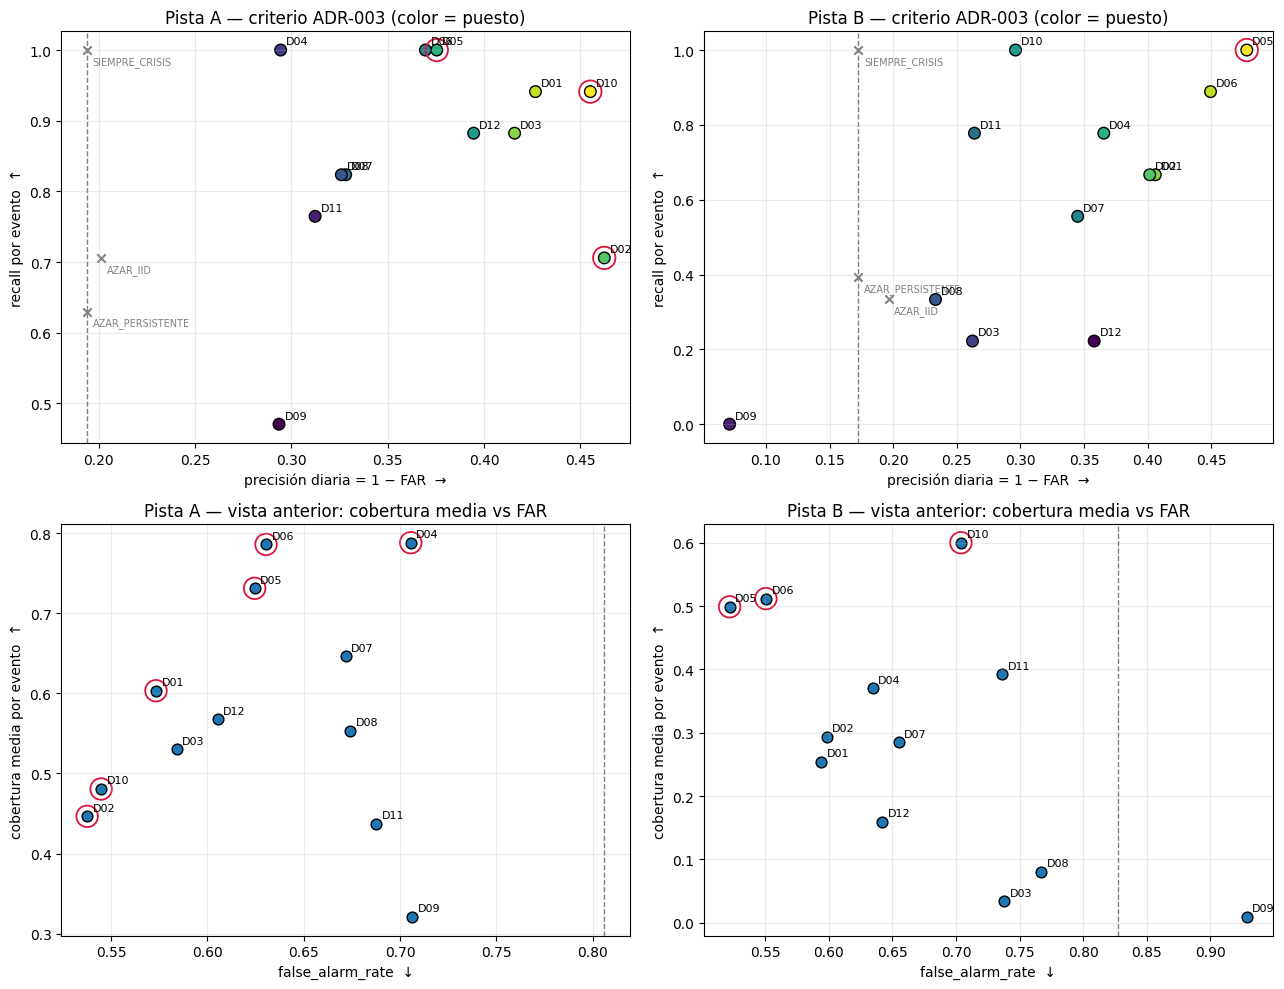

Pista A: tasa base 0.194; frontera recall/precisión: D05 (R=1.00, P=0.38, puesto 5), D10 (R=0.94, P=0.46, puesto 1), D02 (R=0.71, P=0.46, puesto 4)
   1º por score: D10; ¿en la frontera? True. Precisión máxima de la pista = 2.38× la tasa base.
Pista B: tasa base 0.173; frontera recall/precisión: D05 (R=1.00, P=0.48, puesto 1)
   1º por score: D05; ¿en la frontera? True. Precisión máxima de la pista = 2.77× la tasa base.


In [7]:
if LISTO_COMPARAR:
    BASE_RATE = comparison.groupby('pista')['det_base_rate'].first().to_dict()
    comparison['pareto_recall_precision'] = False
    comparison['pareto_cov_far'] = False
    for t in ['A', 'B']:
        mask = comparison.pista == t
        part = comparison[mask]
        comparison.loc[mask, 'pareto_recall_precision'] = rk.pareto_mask(
            part, ['det_event_recall', 'det_precision'])
        comparison.loc[mask, 'pareto_cov_far'] = rk.pareto_mask(
            part.assign(neg_far=-part.false_alarm_rate), ['mean_crisis_coverage', 'neg_far'])
    display(comparison[['pista', 'puesto_deteccion', 'id', 'det_event_recall', 'det_precision',
                        'det_lift_precision', 'pareto_recall_precision', 'pareto_cov_far']].round(3))

    # Líneas base (se construyen en §8; aquí solo como referencia visual).
    def baselines_for(track, part):
        index, _ = rk.track_oos_index(track, metrics, OUTPUT_DIR)
        return rk.trivial_baselines(
            track, index, rate=float(part.det_marked_rate.median()),
            mean_run=float(part.det_mean_crisis_run.median()), min_run=PARAMS['min_run'])
    BASELINES = {t: baselines_for(t, comparison[comparison.pista == t]) for t in ['A', 'B']}

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    for col, track in enumerate(['A', 'B']):
        part = comparison[comparison.pista == track]
        base = BASELINES[track]
        ax = axes[0, col]
        sc = ax.scatter(part.det_precision, part.det_event_recall, s=70, c=part.puesto_deteccion,
                        cmap='viridis_r', edgecolor='black')
        front = part[part.pareto_recall_precision]
        ax.scatter(front.det_precision, front.det_event_recall, s=260, facecolors='none',
                   edgecolors='crimson', linewidths=1.3)
        ax.scatter(base.det_precision, base.det_event_recall, marker='x', color='grey')
        for _, row in base.dropna(subset=['det_precision']).iterrows():
            ax.annotate(row.id, (row.det_precision, row.det_event_recall), fontsize=7, color='grey',
                        xytext=(4, -10), textcoords='offset points')
        ax.axvline(BASE_RATE[track], ls='--', color='grey', lw=1)
        for _, row in part.iterrows():
            ax.annotate(row.id, (row.det_precision, row.det_event_recall),
                        xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set_title(f'Pista {track} — criterio ADR-003 (color = puesto)')
        ax.set_xlabel('precisión diaria = 1 − FAR  →')
        ax.set_ylabel('recall por evento  ↑')
        ax.grid(alpha=.25)
        ax = axes[1, col]
        ax.scatter(part.false_alarm_rate, part.mean_crisis_coverage, s=60, edgecolor='black')
        front = part[part.pareto_cov_far]
        ax.scatter(front.false_alarm_rate, front.mean_crisis_coverage, s=240, facecolors='none',
                   edgecolors='crimson', linewidths=1.3)
        ax.axvline(1 - BASE_RATE[track], ls='--', color='grey', lw=1)
        for _, row in part.iterrows():
            ax.annotate(row.id, (row.false_alarm_rate, row.mean_crisis_coverage),
                        xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set_title(f'Pista {track} — vista anterior: cobertura media vs FAR')
        ax.set_xlabel('false_alarm_rate  ↓')
        ax.set_ylabel('cobertura media por evento  ↑')
        ax.grid(alpha=.25)
    fig.tight_layout()
    plt.show()

    for t in ['A', 'B']:
        part = comparison[comparison.pista == t]
        front = part[part.pareto_recall_precision].sort_values('det_precision')
        print(f"Pista {t}: tasa base {BASE_RATE[t]:.3f}; frontera recall/precisión: "
              + ', '.join(f"{r.id} (R={r.det_event_recall:.2f}, P={r.det_precision:.2f}, puesto {r.puesto_deteccion})"
                          for r in front.itertuples()))
        top = part.iloc[0]
        print(f"   1º por score: {top.id}; ¿en la frontera? {bool(top.pareto_recall_precision)}. "
              f"Precisión máxima de la pista = {part.det_lift_precision.max():.2f}× la tasa base.")

**Lectura.** La frontera es la lista de compromisos no dominados; el score $F_1$ elige
un punto de ella (o cerca) con igual peso a recall y precisión. Si el primero del
ranking no está en la frontera, es porque otro detector lo domina en ambos ejes y
ha caído por otro motivo (nivel o empate); la salida lo indica. El recall por evento
satura con facilidad (varios detectores ven casi todas las crisis), así que dentro de
la frontera la **precisión** es la que más discrimina; la cobertura media de la vista
anterior mezclaba ambas cosas con la duración de los episodios.

## 5. Persistencia, estabilidad y coste

La persistencia ya no entra en el score: aquí se ven los dos filtros de parpadeo
(líneas discontinuas) y la estabilidad frente al coste real medido. Recuérdese que
`label_stability` tiene suelo 0,5 y depende de la frecuencia de refit (§10).

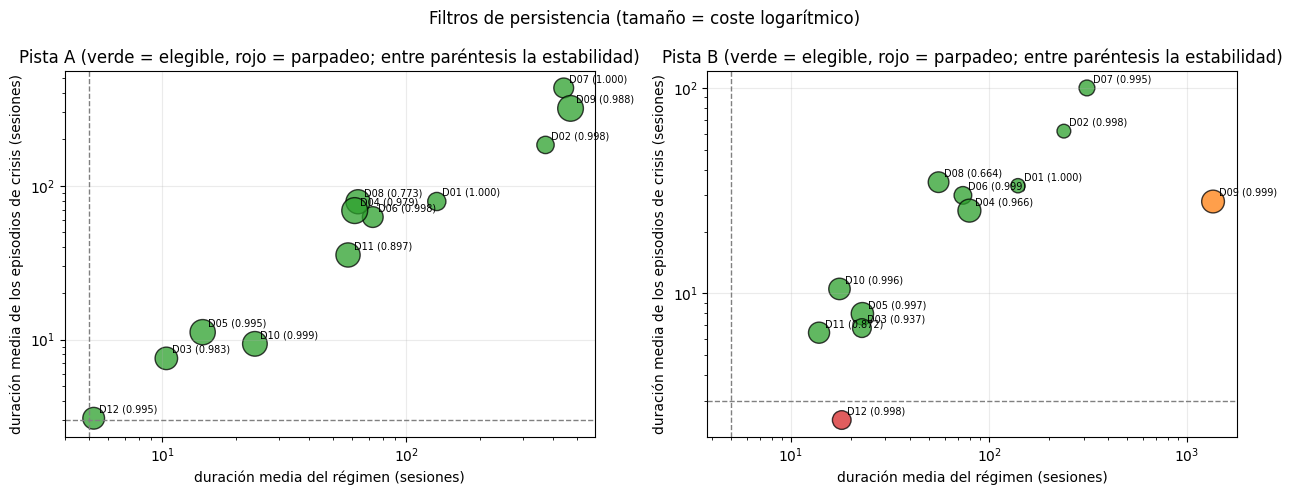

In [8]:
if LISTO_COMPARAR:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, track in zip(axes, ['A', 'B']):
        part = comparison[comparison.pista == track]
        sizes = 40 + 35 * np.log1p(part.elapsed_seconds.fillna(0))
        colors = part.nivel.map({0: 'tab:green', 1: 'tab:orange', 2: 'tab:red', 3: 'black'})
        ax.scatter(part.mean_regime_duration, part.det_mean_crisis_run, s=sizes, c=colors,
                   alpha=.75, edgecolor='black')
        for _, row in part.iterrows():
            ax.annotate(f"{row.id} ({row.label_stability:.3f})",
                        (row.mean_regime_duration, row.det_mean_crisis_run),
                        xytext=(4, 4), textcoords='offset points', fontsize=7)
        ax.axvline(PARAMS['min_mean_duration'], ls='--', color='grey', lw=1)
        ax.axhline(PARAMS['min_crisis_run'], ls='--', color='grey', lw=1)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_title(f'Pista {track} (verde = elegible, rojo = parpadeo; entre paréntesis la estabilidad)')
        ax.set_xlabel('duración media del régimen (sesiones)')
        ax.set_ylabel('duración media de los episodios de crisis (sesiones)')
        ax.grid(alpha=.25)
    fig.suptitle('Filtros de persistencia (tamaño = coste logarítmico)')
    fig.tight_layout()
    plt.show()

## 6. Mapa de ranks por eje (criterio legacy)

Para trazar el cambio de criterio se conserva el mapa de los cinco ejes del
`rank_medio` anterior. Tres de ellos (trampas, switching, estabilidad) premian la
inactividad, que es precisamente lo que ADR-003 corrige.

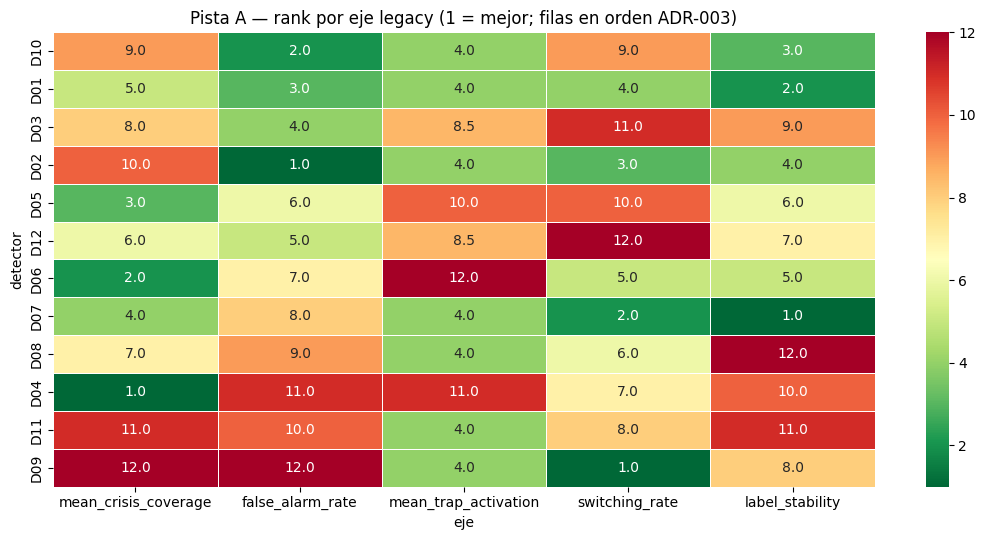

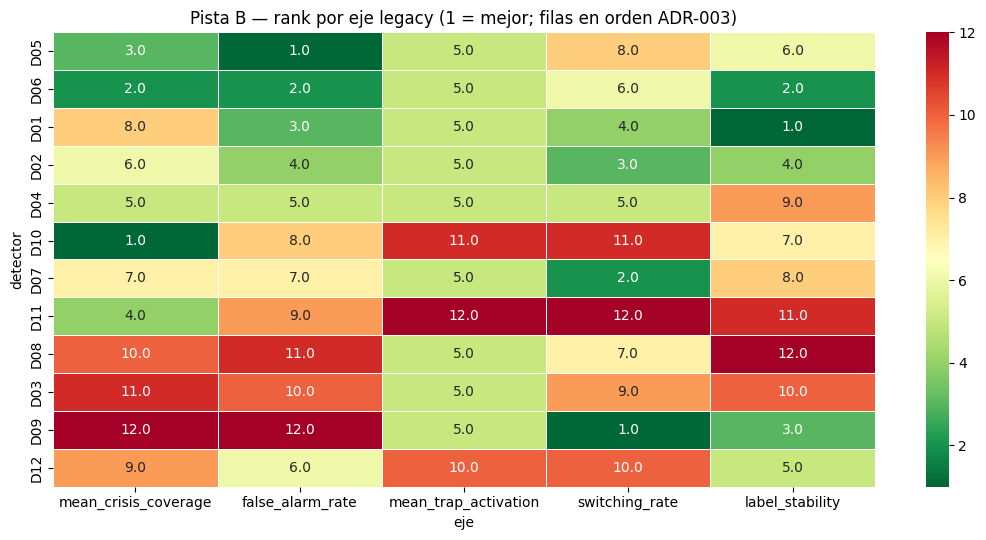

In [9]:
if LISTO_COMPARAR:
    legacy = rk.rank_within_track(metrics)
    rank_cols = [c for c in legacy if c.startswith('rank_') and c != 'rank_medio']
    for track in ['A', 'B']:
        orden = comparison[comparison.pista == track]['id']
        part = legacy[legacy.pista == track].set_index('id').loc[orden, rank_cols]
        part.columns = [c.removeprefix('rank_') for c in part.columns]
        plt.figure(figsize=(11, 5.5))
        sns.heatmap(part, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=.4)
        plt.title(f'Pista {track} — rank por eje legacy (1 = mejor; filas en orden ADR-003)')
        plt.xlabel('eje'); plt.ylabel('detector')
        plt.tight_layout(); plt.show()

## 7. Detección y cobertura por crisis

Arriba, qué eventos detecta cada detector con el criterio de §3 (1 = racha de
`min_run` sesiones dentro de la ventana); abajo, la cobertura continua `cov_<crisis>`.
Filas en orden del ranking de detección; columnas cronológicas; las crisis fuera del
OOS no aparecen.

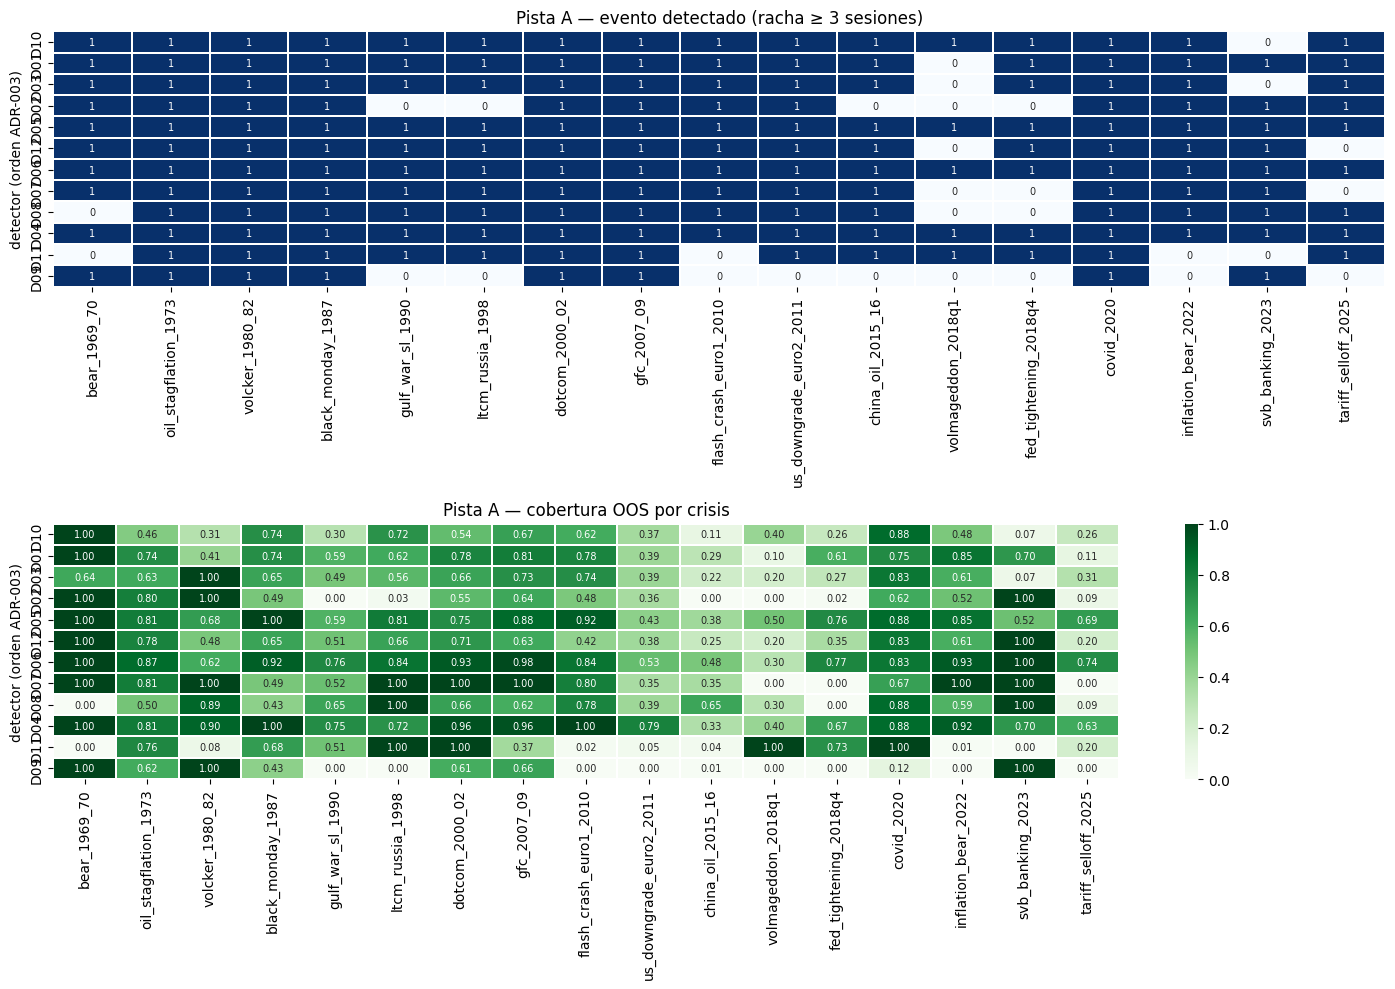

,bear_1969_70,oil_stagflation_1973,volcker_1980_82,black_monday_1987,gulf_war_sl_1990,ltcm_russia_1998,dotcom_2000_02,gfc_2007_09,flash_crash_euro1_2010,us_downgrade_euro2_2011,china_oil_2015_16,volmageddon_2018q1,fed_tightening_2018q4,covid_2020,inflation_bear_2022,svb_banking_2023,tariff_selloff_2025
detectores_que_la_detectan,10.0,12.00,12.00,12.00,10.00,10.00,12.00,12.0,10.00,11.00,10.00,5.00,8.00,12.00,10.00,9.00,9.0
detectores_con_cov≥0.5,10.0,10.00,8.00,8.00,8.00,10.00,12.00,11.0,8.00,2.00,1.00,2.00,5.00,11.00,9.00,9.00,3.0
mediana_cov,1.0,0.77,0.79,0.67,0.52,0.72,0.73,0.7,0.76,0.38,0.27,0.25,0.31,0.83,0.61,0.85,0.2


Pista A: crisis menos detectadas → volmageddon_2018q1 (5/12), fed_tightening_2018q4 (8/12), svb_banking_2023 (9/12)


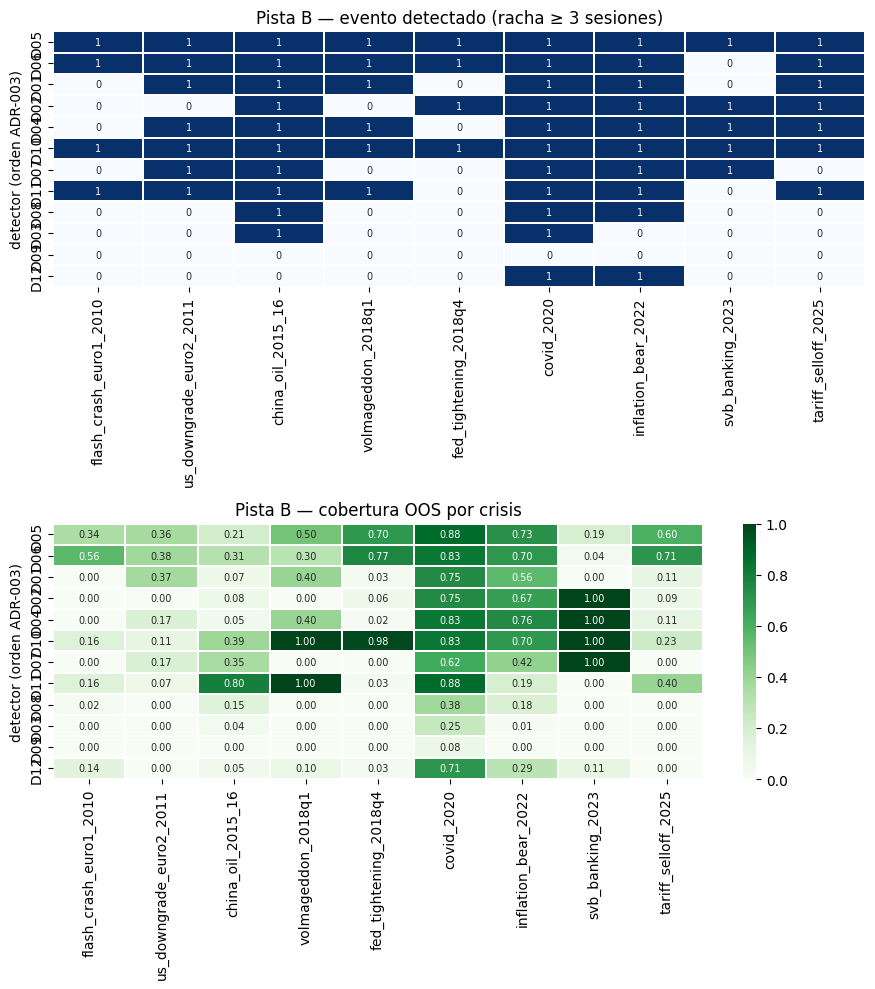

,flash_crash_euro1_2010,us_downgrade_euro2_2011,china_oil_2015_16,volmageddon_2018q1,fed_tightening_2018q4,covid_2020,inflation_bear_2022,svb_banking_2023,tariff_selloff_2025
detectores_que_la_detectan,4.00,7.00,10.00,6.0,4.00,11.00,10.00,5.00,7.0
detectores_con_cov≥0.5,1.00,0.00,1.00,3.0,3.00,9.00,6.00,4.00,2.0
mediana_cov,0.01,0.09,0.12,0.2,0.03,0.75,0.49,0.07,0.1


Pista B: crisis menos detectadas → flash_crash_euro1_2010 (4/12), fed_tightening_2018q4 (4/12), svb_banking_2023 (5/12)


In [10]:
if LISTO_COMPARAR:
    for track in ['A', 'B']:
        part = comparison[comparison.pista == track].set_index('id')
        names = [c for c in SPEC['crisis_windows'][f'pista_{track}'] if part[f'cov_{c}'].notna().any()]
        det = part[[f'det_ev_{c}' for c in names]].rename(columns=lambda c: c.removeprefix('det_ev_'))
        cov = part[[f'cov_{c}' for c in names]].rename(columns=lambda c: c.removeprefix('cov_'))
        fig, axes = plt.subplots(2, 1, figsize=(max(8, 0.65 * len(names) + 3), 10))
        sns.heatmap(det, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=1, cbar=False,
                    linewidths=.3, annot_kws={'fontsize': 7}, ax=axes[0])
        axes[0].set_title(f'Pista {track} — evento detectado (racha ≥ {PARAMS["min_run"]} sesiones)')
        sns.heatmap(cov, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1,
                    linewidths=.3, annot_kws={'fontsize': 7}, ax=axes[1])
        axes[1].set_title(f'Pista {track} — cobertura OOS por crisis')
        for ax in axes:
            ax.set_xlabel(''); ax.set_ylabel('detector (orden ADR-003)')
        fig.tight_layout(); plt.show()
        resumen = pd.concat([det.sum().rename('detectores_que_la_detectan'),
                             (cov >= 0.5).sum().rename('detectores_con_cov≥0.5'),
                             cov.median().rename('mediana_cov').round(2)], axis=1).T
        display(resumen)
        dificiles = det.mean().sort_values().head(3)
        print(f"Pista {track}: crisis menos detectadas → "
              + ', '.join(f"{k} ({int(det[k].sum())}/{len(det)})" for k in dificiles.index))

**Lectura.** Los grandes episodios los detecta casi cualquier familia, de modo que el
recall por evento discrimina sobre todo en los episodios cortos o atípicos (la salida
anterior lista los menos detectados por pista). La cobertura continua sigue siendo útil
para ver **cuánto** de cada episodio se marca, pero ya no pondera por igual un evento de
diez sesiones y uno de seiscientas en el criterio principal.

## 8. Robustez del criterio

Cuatro pruebas, todas sobre las métricas ya calculadas (no se reajusta nada):

1. **Líneas base triviales** (`rk.trivial_baselines`): `SIEMPRE_CRISIS`, `SIEMPRE_CALMA`,
   `AZAR_IID` (Bernoulli diario con la tasa de marcado mediana de la pista) y
   `AZAR_PERSISTENTE` (Markov con esa tasa y la duración mediana de los episodios de
   crisis; fila = media de 200 simulaciones, precisión en su valor esperado = tasa base).
   Con el criterio nuevo deben quedar al fondo (lo garantiza
   `tests/test_ranking_detection.py`); se compara con dónde las pondría el `rank_medio`.
2. **Sensibilidad a los parámetros** (`beta`, `min_run`, `lift_min`, filtros).
3. **Nulo de azar persistente por detector**: p-valor empírico del score frente a una
   señal de Markov independiente de las crisis con la **misma** tasa de marcado y la
   misma duración de episodios que el detector.
4. **Leave-one-crisis-out** sobre el recall por evento.

Estas filas **no** se exportan.

In [11]:
if LISTO_COMPARAR:
    base_rows = pd.concat(BASELINES.values(), ignore_index=True)
    with_baselines = rk.rank_detection(pd.concat([metrics, base_rows], ignore_index=True),
                                       output_dir=OUTPUT_DIR, **PARAMS)
    nombres_base = set(base_rows.id)
    display(with_baselines[['pista', 'puesto_deteccion', 'id', 'nivel_etiqueta', 'score_deteccion',
                            'det_event_recall', 'det_precision', 'det_lift_precision',
                            'det_mean_crisis_run', 'puesto_legacy']].round(3))
    for t, part in with_baselines.groupby('pista'):
        n = len(part)
        reales = part[~part.id.isin(nombres_base)]
        pos = part.set_index('id')
        print(f"Pista {t} ({n} filas): " + ', '.join(
            f"{b} {int(pos.loc[b, 'puesto_deteccion'])}º (legacy {int(pos.loc[b, 'puesto_legacy'])}º)"
            for b in ['SIEMPRE_CRISIS', 'SIEMPRE_CALMA', 'AZAR_IID', 'AZAR_PERSISTENTE']))
        peor_que_trivial = reales[reales.score_deteccion < pos.loc['SIEMPRE_CRISIS', 'score_deteccion']]
        print(f"   detectores reales con score < SIEMPRE_CRISIS (quedan encima solo por el nivel): "
              f"{', '.join(peor_que_trivial.id) or '—'}")
        bajo_azar = reales[reales.puesto_deteccion > pos.loc['AZAR_PERSISTENTE', 'puesto_deteccion']]
        print(f"   detectores reales por debajo de AZAR_PERSISTENTE: "
              + (', '.join(f"{r.id} ({int(r.puesto_deteccion)}º, {r.nivel_etiqueta})" for r in bajo_azar.itertuples())
                 or '—'))
        elegibles = reales[reales.nivel_etiqueta == 'elegible']
        print(f"   ¿todas las líneas base por debajo de todos los detectores elegibles? "
              f"{'sí' if all(pos.loc[b, 'puesto_deteccion'] > elegibles.puesto_deteccion.max() for b in nombres_base) else 'no'}")

,pista,puesto_deteccion,id,nivel_etiqueta,score_deteccion,det_event_recall,det_precision,det_lift_precision,det_mean_crisis_run,puesto_legacy
0,A,1,D10,elegible,0.614,0.941,0.455,2.347,9.383,4.0
1,A,2,D01,elegible,0.587,0.941,0.427,2.200,79.019,1.0
2,A,3,D03,elegible,0.565,0.882,0.416,2.144,7.549,13.0
3,A,4,D02,elegible,0.559,0.706,0.462,2.384,184.263,3.0
4,A,5,D05,elegible,0.546,1.000,0.375,1.936,11.172,8.0
5,A,6,D12,elegible,0.545,0.882,0.395,2.035,3.080,11.0
6,A,7,D06,elegible,0.540,1.000,0.370,1.906,62.598,6.0
7,A,8,D07,elegible,0.469,0.824,0.328,1.692,432.500,1.0
8,A,9,D08,elegible,0.467,0.824,0.326,1.681,78.716,9.0
9,A,10,D04,elegible,0.455,1.000,0.294,1.518,68.965,12.0


Pista A (16 filas): SIEMPRE_CRISIS 15º (legacy 5º), SIEMPRE_CALMA 16º (legacy 7º), AZAR_IID 14º (legacy 16º), AZAR_PERSISTENTE 13º (legacy 15º)
   detectores reales con score < SIEMPRE_CRISIS (quedan encima solo por el nivel): —
   detectores reales por debajo de AZAR_PERSISTENTE: —
   ¿todas las líneas base por debajo de todos los detectores elegibles? sí
Pista B (16 filas): SIEMPRE_CRISIS 15º (legacy 5º), SIEMPRE_CALMA 16º (legacy 8º), AZAR_IID 14º (legacy 16º), AZAR_PERSISTENTE 11º (legacy 15º)
   detectores reales con score < SIEMPRE_CRISIS (quedan encima solo por el nivel): D08, D03, D09, D12
   detectores reales por debajo de AZAR_PERSISTENTE: D09 (12º, precision_no_supera_azar), D12 (13º, parpadeo)
   ¿todas las líneas base por debajo de todos los detectores elegibles? sí


In [12]:
if LISTO_COMPARAR:
    variantes = {'oficial': PARAMS}
    for beta in (0.5, 2.0):
        variantes[f'beta={beta:g}'] = {**PARAMS, 'beta': beta}
    for min_run in (1, 5):
        variantes[f'min_run={min_run}'] = {**PARAMS, 'min_run': min_run}
    variantes['lift_min=1.5'] = {**PARAMS, 'lift_min': 1.5}
    variantes['sin_filtros_persistencia'] = {**PARAMS, 'min_mean_duration': 0.0, 'min_crisis_run': 0.0}
    variantes['min_crisis_run=5'] = {**PARAMS, 'min_crisis_run': 5.0}
    sens = {}
    for name, params in variantes.items():
        r = rk.rank_detection(metrics, output_dir=OUTPUT_DIR, **params)
        sens[name] = r.set_index(['pista', 'id'])['puesto_deteccion']
    sens_params = pd.DataFrame(sens)
    sens_params['puesto_min'] = sens_params.min(axis=1)
    sens_params['puesto_max'] = sens_params.max(axis=1)
    display(sens_params.sort_values(['pista', 'oficial']).astype(int))
    for t in ['A', 'B']:
        p = sens_params.loc[t]
        podio = p[p.oficial <= 3].sort_values('oficial')
        print(f"Pista {t}: podio oficial " + ', '.join(
            f"{i} ({int(r.puesto_min)}–{int(r.puesto_max)})" for i, r in podio.iterrows())
            + f"; nº 1 estable en todas las variantes: {', '.join(p.index[p.puesto_max == 1]) or 'ninguno'}")

oficial  beta=0.5  beta=2  min_run=1  min_run=5  lift_min=1.5  sin_filtros_persistencia  min_crisis_run=5  puesto_min  puesto_max
pista id                                                                                                                                    
A     D10        1         1       1          1          1             1                         1                 1           1           1
      D01        2         3       2          2          2             2                         2                 2           2           3
      D03        3         4       5          4          5             3                         3                 3           3           5
      D02        4         2       8          3          4             4                         4                 4           2           8
      D05        5         6       3          6          3             5                         5                 5           3           6
      D12        6         5       6          5          6             6                         6                12           5          12
      D06        7         7       4          7          7             7                         7                 6           4           7
      D07        8         8       9          9          8             8                         8                 7           7           9
      D08        9         9      10          8          9             9                         9                 8           8          10
      D04       10        11       7         11         10            10                        10                 9           7          11
      D11       11        10      11         10         11            11                        11                10          10          11
      D09       12        12      12         12         12            12                        12                11          11          12
B     D05        1         1       1          1          1             1                         1                 1           1           1
      D06        2         2       2          2          2             2                         2                 2           2           2
      D01        3         3       5          3          5             3                         3                 3           3           5
      D02        4         4       6          5          6             4                         4                 4           4           6
      D04        5         5       4          4          7             5                         5                 5           4           7
      D10        6         7       3          6          3             6                         6                 6           3           7
      D07        7         6       8          7          4             7                         7                 7           4           8
      D11        8         8       7          8          8             8                         8                 8           7           8
      D08        9        10       9          9          9            10                         9                 9           9          10
      D03       10         9      10         10         10             9                        11                10           9          11
      D09       11        11      11         11         11            11                        12                11          11          12
      D12       12        12      12         12         12            12                        10                12          10          12

Pista A: podio oficial D10 (1–1), D01 (2–3), D03 (3–5); nº 1 estable en todas las variantes: D10
Pista B: podio oficial D05 (1–1), D06 (2–2), D01 (3–5); nº 1 estable en todas las variantes: D05


In [13]:
if LISTO_COMPARAR:
    N_SIMS = 200
    pvals = []
    for t in ['A', 'B']:
        index, exacto = rk.track_oos_index(t, metrics, OUTPUT_DIR)
        windows = rk.track_crisis_windows(t)
        for i, row in enumerate(comparison[comparison.pista == t].itertuples()):
            if row.nivel == 3 or not np.isfinite(row.det_mean_crisis_run):
                continue
            null = rk.persistent_random_null(
                index, windows, rate=row.det_marked_rate, mean_run=row.det_mean_crisis_run,
                n_sims=N_SIMS, seed=1000 + i, min_run=PARAMS['min_run'], beta=PARAMS['beta'])
            pvals.append({
                'pista': t, 'id': row.id, 'puesto_deteccion': row.puesto_deteccion,
                'score': row.score_deteccion, 'score_nulo_medio': null.score_deteccion.mean(),
                'score_nulo_p95': null.score_deteccion.quantile(.95),
                'lift': row.det_lift_precision, 'lift_nulo_p95': null.det_lift_precision.quantile(.95),
                'p_valor': (1 + (null.score_deteccion >= row.score_deteccion).sum()) / (1 + N_SIMS),
            })
    nulo = pd.DataFrame(pvals)
    display(nulo.round(3))
    for t, part in nulo.groupby('pista'):
        print(f"Pista {t}: p < 0,05 frente al azar persistente con su misma tasa y persistencia: "
              f"{', '.join(part[part.p_valor < .05].id) or 'ninguno'}; "
              f"p ≥ 0,05: {', '.join(part[part.p_valor >= .05].id) or 'ninguno'}")

,pista,id,puesto_deteccion,score,score_nulo_medio,score_nulo_p95,lift,lift_nulo_p95,p_valor
0,A,D10,1,0.614,0.305,0.360,2.347,1.239,0.005
1,A,D01,2,0.587,0.284,0.360,2.200,1.333,0.005
2,A,D03,3,0.565,0.315,0.351,2.144,1.125,0.005
3,A,D02,4,0.559,0.254,0.348,2.384,1.494,0.005
4,A,D05,5,0.546,0.316,0.351,1.936,1.123,0.005
5,A,D12,6,0.545,0.318,0.341,2.035,1.088,0.005
6,A,D06,7,0.540,0.309,0.377,1.906,1.262,0.005
7,A,D07,8,0.469,0.285,0.363,1.692,1.322,0.005
8,A,D08,9,0.467,0.299,0.377,1.681,1.359,0.005
9,A,D04,10,0.455,0.312,0.363,1.518,1.181,0.005


Pista A: p < 0,05 frente al azar persistente con su misma tasa y persistencia: D10, D01, D03, D02, D05, D12, D06, D07, D08, D04, D11; p ≥ 0,05: D09
Pista B: p < 0,05 frente al azar persistente con su misma tasa y persistencia: D05, D06, D01, D02, D04, D10, D07, D11; p ≥ 0,05: D08, D03, D09, D12


In [14]:
if LISTO_COMPARAR:
    loco = {}
    for t in ['A', 'B']:
        part = comparison[comparison.pista == t]
        ev_cols = [c for c in part if c.startswith('det_ev_') and part[c].notna().any()]
        for c in ev_cols:
            alt = comparison[comparison.pista == t].copy()
            resto = [x for x in ev_cols if x != c]
            alt['det_event_recall'] = alt[resto].mean(axis=1, skipna=True)
            r = rk.rank_detection(alt, output_dir=OUTPUT_DIR, **PARAMS)
            loco[(t, c)] = r.set_index('id')['puesto_deteccion']
    loco_tab = pd.DataFrame({
        t: pd.concat([loco[k] for k in loco if k[0] == t], axis=1)
        .agg(['min', 'max'], axis=1).apply(lambda s: f"{int(s['min'])}–{int(s['max'])}", axis=1)
        for t in ['A', 'B']})
    loco_tab.index.name = 'id'
    print('Rango de puestos al quitar una crisis cada vez (leave-one-crisis-out):')
    display(loco_tab)

Rango de puestos al quitar una crisis cada vez (leave-one-crisis-out):


,A,B
id,,
D01,2–2,3–4
D02,3–5,3–5
D03,3–4,9–10
D04,10–10,4–5
D05,5–6,1–1
D06,7–7,2–2
D07,8–9,7–7
D08,8–9,9–10
D09,12–12,11–11


**Lectura de la robustez.** Las salidas anteriores responden a cuatro preguntas.

1. **¿Quedan las líneas base al fondo?** Solo frente a los detectores **elegibles**. Por
   construcción de niveles, la salida constante y el parpadeo caen al fondo, y el azar
   persistente, con lift esperado 1, no pasa la restricción de precisión. Pero un
   detector real que tampoco la pasa, o que parpadea, comparte nivel con las líneas base
   y se ordena por score dentro de él. Por eso, en la pista B, `AZAR_PERSISTENTE` queda
   por encima de detectores reales no elegibles (la primera celda de §8 los lista), y
   varios detectores reales puntúan por debajo de `SIEMPRE_CRISIS`: solo el nivel los
   deja por encima.
2. **¿Dónde las ponía el `rank_medio`?** Por encima de parte de los detectores reales.
3. **¿Cuánto se mueven los puestos** al cambiar parámetros o al quitar una crisis?
4. **¿Qué detectores superan al azar con su misma tasa y persistencia?** Esta prueba es
   más exigente que `lift > 1`. Con pocos eventos, un nulo persistente produce
   precisiones muy dispersas, y un detector puede superar la tasa base sin ser
   distinguible del azar. En B, varios detectores (listados en la salida) no se
   distinguen del azar persistente (p ≥ 0,05). El p-valor es informativo y no un filtro
   del ranking.

## 9. Comparación con el `rank_medio` anterior

`puesto_legacy` es el puesto por `rank_medio` (media de cinco rangos) que publicaba la
versión anterior de este notebook y que sigue en `metrics_master_v2.csv`.

,pista,id,puesto_deteccion,puesto_legacy,rank_medio_legacy,nivel_etiqueta,cambio
0,A,D10,1,4.0,5.4,elegible,3.0
1,A,D01,2,1.0,3.6,elegible,-1.0
2,A,D03,3,11.0,8.1,elegible,8.0
3,A,D02,4,3.0,4.4,elegible,-1.0
4,A,D05,5,6.0,7.0,elegible,1.0
5,A,D12,6,9.0,7.7,elegible,3.0
6,A,D06,7,5.0,6.2,elegible,-2.0
7,A,D07,8,2.0,3.8,elegible,-6.0
8,A,D08,9,8.0,7.6,elegible,-1.0
9,A,D04,10,10.0,8.0,elegible,0.0


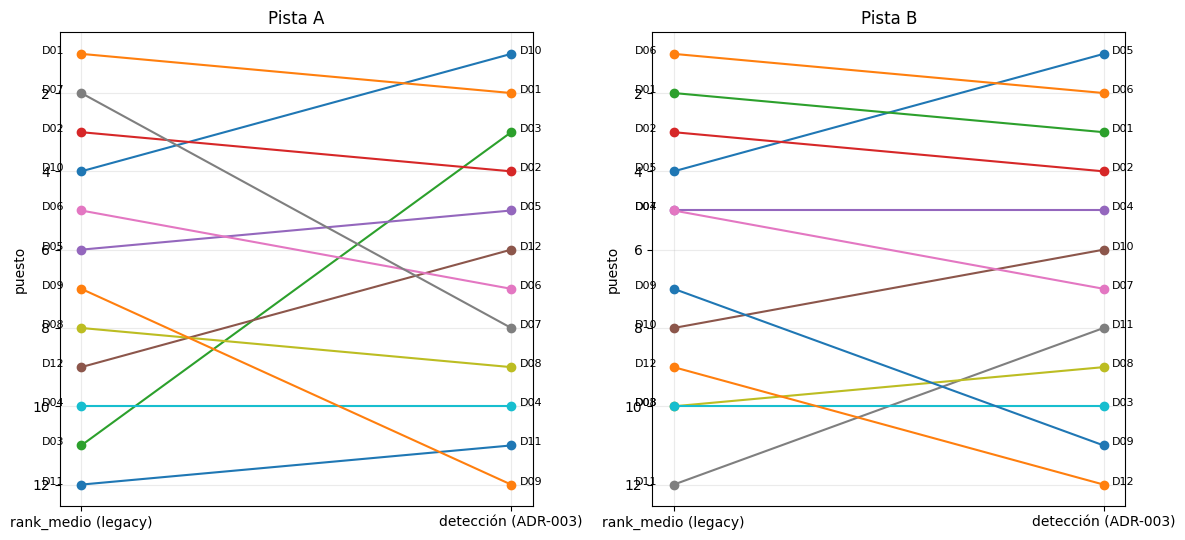

Pista A: Spearman(nuevo, legacy) = 0.47; 1º nuevo D10 vs 1º legacy D01; más sube D03 (11º→3º), más baja D07 (2º→8º)
Pista B: Spearman(nuevo, legacy) = 0.78; 1º nuevo D05 vs 1º legacy D06; más sube D11 (12º→8º), más baja D09 (7º→11º)


In [15]:
if LISTO_COMPARAR:
    cmp_legacy = comparison[['pista', 'id', 'puesto_deteccion', 'puesto_legacy', 'rank_medio_legacy',
                             'nivel_etiqueta']].copy()
    cmp_legacy['cambio'] = cmp_legacy.puesto_legacy - cmp_legacy.puesto_deteccion
    display(cmp_legacy.sort_values(['pista', 'puesto_deteccion']).round(2))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    for ax, (t, part) in zip(axes, cmp_legacy.groupby('pista')):
        for _, row in part.iterrows():
            ax.plot([0, 1], [row.puesto_legacy, row.puesto_deteccion], marker='o')
            ax.annotate(row.id, (0, row.puesto_legacy), xytext=(-28, 0), textcoords='offset points', fontsize=8)
            ax.annotate(row.id, (1, row.puesto_deteccion), xytext=(6, 0), textcoords='offset points', fontsize=8)
        ax.set_xticks([0, 1], ['rank_medio (legacy)', 'detección (ADR-003)'])
        ax.invert_yaxis(); ax.set_ylabel('puesto'); ax.set_title(f'Pista {t}')
        ax.grid(alpha=.25)
    fig.tight_layout(); plt.show()
    for t, part in cmp_legacy.groupby('pista'):
        rho = part[['puesto_deteccion', 'puesto_legacy']].corr(method='spearman').iloc[0, 1]
        sube = part.sort_values('cambio', ascending=False).iloc[0]
        baja = part.sort_values('cambio').iloc[0]
        top_new = part.loc[part.puesto_deteccion.idxmin(), 'id']
        top_old = part.loc[part.puesto_legacy.idxmin(), 'id']
        print(f"Pista {t}: Spearman(nuevo, legacy) = {rho:.2f}; 1º nuevo {top_new} vs 1º legacy {top_old}; "
              f"más sube {sube.id} ({int(sube.puesto_legacy)}º→{int(sube.puesto_deteccion)}º), "
              f"más baja {baja.id} ({int(baja.puesto_legacy)}º→{int(baja.puesto_deteccion)}º)")

## 10. Limitaciones que condicionan la lectura

1. **Umbrales convencionales.** `min_run`, `beta`, `lift_min` y los filtros de persistencia
   son elecciones explícitas (§3), no estimadas; §8 muestra cuánto mueven el orden.
2. **Pocos eventos** por pista: el recall por evento se mueve en saltos de 1/N y el nulo
   de azar persistente es ancho (§8). No hay contraste formal de significación *entre*
   detectores.
3. **Precisión con ventanas `[pico, suelo]`**: todo lo marcado en la recuperación tras el
   suelo (volatilidad aún alta) cuenta como falsa alarma; castiga a los detectores de
   volatilidad. Afecta igual al criterio nuevo y al anterior.
4. **Fuente aproximada** para métricas previas a ADR-003 sin panel local (§3). Ya no
   aplica: tras la re-ejecución completa todas las filas traen `fuente_deteccion = csv`
   (tabla de §3). Se mantiene el código por si se cargan métricas antiguas.
5. **Autómatas y lags.** Las métricas versionadas ya incorporan las correcciones de
   ADR-003 (propagación de estado entre refits, lags de publicación de series mensuales):
   proceden del benchmark completo, cuyo `manifest.json` muestra la tabla de procedencia
   de §1 y que reproduce exactamente las cifras de ADR-003 §4. Cualquier cambio futuro de código o datos
   invalida la huella de caché y obliga a re-ejecutar (04 §4).
6. **`label_stability`** vive en [0,5; 1] y depende de la frecuencia de refit; ahora solo
   desempata.
7. **Trampas** (`taper_2013`, `debtceiling_2013`) no entran en el criterio principal (se
   activan casi siempre a 0); se conservan como diagnóstico en la tabla.
8. **B sin la GFC fuera de muestra** y con un entrenamiento inicial dominado por ella: los
   modelos de clustering/estado latente quedan anclados a esa crisis.
9. **BIC, silueta y logL** se calculan con un ajuste final in-sample y features distintas
   por detector: no son comparables y no entran en el ranking.

## 11. Qué se decide después — no en este notebook

Con el criterio fijado, las alternativas siguen siendo tres: **detector único** (si uno
lidera ambas pistas de forma estable en §8), **híbrido de dos velocidades** (un núcleo
persistente con una alarma rápida, si §7 muestra que sus eventos detectados son
complementarios) o **detector nuevo** (solo si ningún candidato supera con claridad al
azar persistente). La decisión deberá escribirse en una ADR que congele modelo,
features, hiperparámetros y regla de refit, y validarse después en pseudolive sobre un
periodo final no usado para elegirla.

In [16]:
if LISTO_COMPARAR:
    podium = comparison.loc[comparison['puesto_deteccion'] <= 3, rk.RANKING_COLUMNS]
    print('Podio por pista con el criterio de detección (no decisión final):')
    display(podium.round(4))
    for t in ['A', 'B']:
        top = comparison[(comparison.pista == t) & (comparison.puesto_deteccion == 1)].iloc[0]
        print(f"Pista {t}: 1º {top.id} ({top.detector}) — F{PARAMS['beta']:g} {top.score_deteccion:.3f}, "
              f"recall por evento {top.det_event_recall:.3f} ({int(top.det_n_detectados)}/{int(top.det_n_eventos)}), "
              f"precisión {top.det_precision:.3f} (lift {top.det_lift_precision:.2f}), "
              f"puesto legacy {int(top.puesto_legacy)}º")
else:
    print('Pendiente: completar y validar 04_protocolo_evaluacion.ipynb '
          '(python -m regimenes.benchmark --track A B --jobs 4).')

Podio por pista con el criterio de detección (no decisión final):


,pista,puesto_deteccion,id,detector,familia,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_day_recall,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds,fuente_deteccion,rank_medio_legacy,puesto_legacy
0,A,1,D10,turbulence_mahalanobis,Reglas multivariantes,elegible,0.6136,0.9412,16,17,0.4552,2.3471,0.1939,0.1959,0.4597,9.3831,0.4806,0.5448,0.0000,0.0417,23.9542,0.9991,2612.3032,csv,5.4,4.0
1,A,2,D01,rule_vix_threshold,Reglas,elegible,0.5872,0.9412,16,17,0.4267,2.2001,0.1939,0.2963,0.6520,79.0189,0.6034,0.5733,0.0000,0.0074,133.3302,0.9998,41.7145,csv,3.6,1.0
2,A,3,D03,clustering_gmm_k3,Clustering,elegible,0.5653,0.8824,15,17,0.4159,2.1444,0.1939,0.3028,0.6494,7.5485,0.5303,0.5841,0.0053,0.0962,10.3843,0.9832,578.5258,csv,8.1,11.0
12,B,1,D05,markov_switching_var_2s,Markov-Switching,elegible,0.6467,1.0000,9,9,0.4779,2.7671,0.1727,0.1727,0.4779,7.9659,0.4990,0.5221,0.0000,0.0434,22.9322,0.9973,512.7000,csv,4.6,4.0
13,B,2,D06,garch_t_vol,GARCH,elegible,0.5970,0.8889,8,9,0.4494,2.6021,0.1727,0.1996,0.5193,30.0000,0.5119,0.5506,0.0000,0.0133,73.8000,0.9994,31.1622,csv,3.4,1.0
14,B,3,D01,rule_vix_threshold,Reglas,elegible,0.5046,0.6667,6,9,0.4060,2.3508,0.1727,0.1153,0.2710,33.4286,0.2543,0.5940,0.0000,0.0069,139.9655,0.9999,5.5607,csv,4.2,2.0


Pista A: 1º D10 (turbulence_mahalanobis) — F1 0.614, recall por evento 0.941 (16/17), precisión 0.455 (lift 2.35), puesto legacy 4º
Pista B: 1º D05 (markov_switching_var_2s) — F1 0.647, recall por evento 1.000 (9/9), precisión 0.478 (lift 2.77), puesto legacy 4º


## 12. Cierre

`12_comparativa.ipynb` produce una comparación reproducible con un criterio de
detección explícito, no una conclusión automática. Entregables: `ranking_v2.csv`
(criterio ADR-003 con `rank_medio_legacy`/`puesto_legacy` para comparar), la frontera de
Pareto, la detección por crisis, las pruebas de robustez frente a líneas base y azar, y
la lista de limitaciones. `metrics_master_v2.csv` no se reescribe aquí.